### **Chunk 10: The Residual Connection (ResNet) - The Crucible**

**The Challenge:** Our ResNet-18, engineered in the clean environment of CIFAR-10, performed well. But was that because the model is genuinely powerful, or because the task was relatively simple? The Crucible will answer this.

*   **Concept:** Stress-testing the ResNet-18's ability to learn fine-grained features.
*   **Dataset:** `CIFAR-100`. This dataset has the **same number of images** (50,000 train, 10,000 test) and the **same image size** (32x32) as CIFAR-10, but with **100 classes** instead of 10.
*   **The Crucible Effect:** With only 500 training images per class (down from 5000), the model is starved for data. It can no longer succeed by learning simple features. It must learn to distinguish between highly similar classes (e.g., "oak tree" vs. "maple tree," "otter" vs. "beaver"). This dramatically increases the risk of overfitting and exposes the true generalization power of our architecture.
*   **Goal:** Adapt our existing code to handle 100 classes, train the model, and then perform a deep, glass-box analysis to understand its new failure modes in a data-scarce, fine-grained environment.

In [1]:
# --- Imports ---
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# --- Matplotlib and Seaborn Settings ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

-----

### Load CIFAR-100 Dataset 

In [2]:
# We will download it into its own sub-directory within the Crucible's data folder.
train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True)
test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True)

# --- Load Class Names ---
# The labels in CIFAR-100 are just indices 0-99. We need to map them to actual names.
# Source: https://www.cs.toronto.edu/~kriz/cifar.html
cifar100_classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman',
    'worm'
]
print(f"Training samples : {len(train_dataset)}")
print(F"Test Samples : {len(test_dataset)}")
print(F"Image Shape : {train_dataset.data[0].shape}")

Training samples : 50000
Test Samples : 10000
Image Shape : (32, 32, 3)


*Note the counts. 50,000 training images, same as CIFAR-10. But divided by 100 classes? That's the bottleneck*

**The Class Hierarchy**

In [15]:
classes = train_dataset.classes
print(f"Total Classes : {len(classes)}")
print()
print(f"First 10 classes : {classes[:10]}")
print(f"Last 10 classes : {classes[-10:]}")

# Let's look at scarcity
targets = train_dataset.targets
counts = Counter(targets) 
# Counter is simply counting the amount of every label in the targets List
# len(targets) is 50000
# unique values in targets is 100
# So COUNTER is just creating a dictionary of how many times each class occurs
print(counts)
min_count = min(counts.values())# Key, value remember
max_count = max(counts.values())
print(f"\nSamples per class (Min) : {min_count}")
print(f"Samples per class (Max) : {max_count}")


Total Classes : 100

First 10 classes : ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle']
Last 10 classes : ['train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm']
Counter({19: 500, 29: 500, 0: 500, 11: 500, 1: 500, 86: 500, 90: 500, 28: 500, 23: 500, 31: 500, 39: 500, 96: 500, 82: 500, 17: 500, 71: 500, 8: 500, 97: 500, 80: 500, 74: 500, 59: 500, 70: 500, 87: 500, 84: 500, 64: 500, 52: 500, 42: 500, 47: 500, 65: 500, 21: 500, 22: 500, 81: 500, 24: 500, 78: 500, 45: 500, 49: 500, 56: 500, 76: 500, 89: 500, 73: 500, 14: 500, 9: 500, 6: 500, 20: 500, 98: 500, 36: 500, 55: 500, 72: 500, 43: 500, 51: 500, 35: 500, 83: 500, 33: 500, 27: 500, 53: 500, 92: 500, 50: 500, 15: 500, 18: 500, 46: 500, 75: 500, 38: 500, 66: 500, 77: 500, 69: 500, 95: 500, 99: 500, 93: 500, 4: 500, 61: 500, 94: 500, 68: 500, 34: 500, 32: 500, 88: 500, 67: 500, 30: 500, 62: 500, 63: 500, 40: 500, 26: 500, 48: 500, 79: 500, 85: 

*We have exactly 500 images per class. In Deep Learning, 500 images is considered "low resource" for training from scratch. This confirms that **overfitting** will be our primary antagonist. Our ResNet must be powerful enough to learn features, but regulated enough not to memorize these few samples.*

**Visualizing the Complexity**

<class 'numpy.ndarray'>

 [ 3442 19836  2043 31957 38964 25603 15448  1841 38637 29636 24376 36069
 38910 44159 43034 13456 15429 42159 41531 28644]
Shape of indices : [ 3442 19836  2043 31957 38964 25603 15448  1841 38637 29636 24376 36069
 38910 44159 43034 13456 15429 42159 41531 28644]


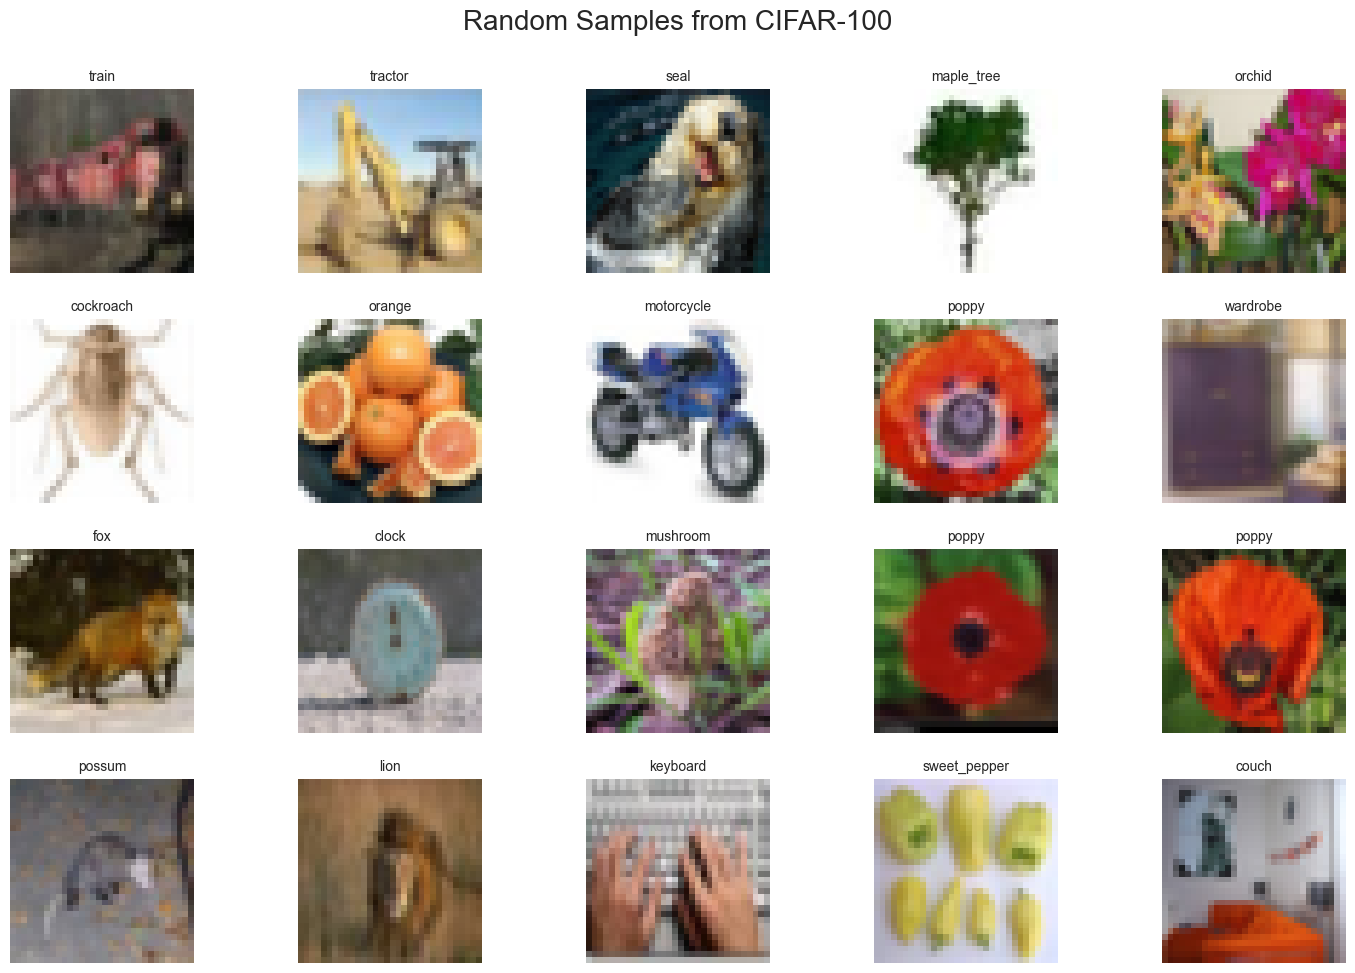

In [17]:
def show_samples(dataset, num_samples=20, cols=5):
    plt.figure(figsize=(15, 10))
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    print(type(indices))
    print("\n",indices)
    print(f"Shape of indices : {indices}")
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        class_name = classes[label]

        plt.subplot(int(np.ceil(num_samples/cols)), cols, i + 1)
        plt.imshow(img)
        plt.title(class_name, fontsize=10)
        plt.axis('off')
    plt.suptitle("Random Samples from CIFAR-100", fontsize=20)
    plt.tight_layout()
    plt.show()
show_samples(train_dataset)

**Calculate mean and std**
> We need specific stats for cifar-100, we cannot reuse CIFAR-10 stats


Mean : [0.50707516 0.48654887 0.44091784]
Std : [0.26733429 0.25643846 0.27615047]


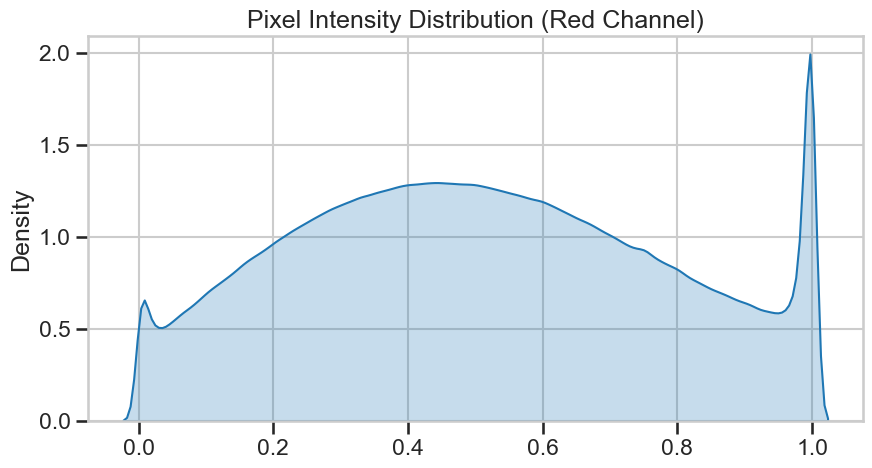

In [22]:
data = train_dataset.data / 255.0 # Scale to [0, 1] temporarily
mean = data.mean(axis= (0, 1, 2)) # mean over [all_images, height, width]
std = data.std(axis=(0, 1, 2)) # std over [all_images, height, width]
print(f"Mean : {mean}")
print(f"Std : {std}")

# Let's verify the distribution of a single channel
plt.figure(figsize=(10, 5))
sns.kdeplot(data[..., 0].flatten(), fill=True, label='Red Channel')
plt.title("Pixel Intensity Distribution (Red Channel)")
plt.show()

*We calculate the mean and standard deviation. These numbers( `Mean : [0.50707516 0.48654887 0.44091784]`
`Std : [0.26733429 0.25643846 0.27615047]`) will be hardcoded into our dataset.py*

### EDA Summary

1.  **The Data Scarcity Problem**: We have 100 classes but only 500 training images per class. This is 1/10th the data density of CIFAR-10.
     *   *Implication:* We must use **heavy data augmentation** (RandomCrop, HorizontalFlip, maybe Rotation or Cutout) to artificially increase the dataset size.
     *   *Implication:* We might need higher weight decay (L2 regularization) in the optimizer.

2.  **The Fine-Grained Challenge**: Classes are semantically similar (e.g., 'maple_tree' vs 'oak_tree', 'seal' vs 'otter').
     *   *Implication:* The model requires significant depth (ResNet-34 or deeper) to learn the hierarchical features necessary to distinguish these subtle differences.

3.  **Action Plan**:
     *   **Architecture**: ResNet-34 (Standard ResNet-18 might underfit the complexity, or overfit due to lack of regularization capacity. ResNet-34 provides a good balance for 32x32 images).
     *   **Normalization**: Use the calculated Mean/Std.
     *   **Metric**: Top-1 Accuracy is hard. We should also monitor **Top-5 Accuracy** (is the correct answer in the model's top 5 guesses?) during training to gauge progress.